# ET7008 - Digital Management
## Classification Module (Part 1: Foundations)

Welcome to this practical classification lab! In this notebook, we will explore the fundamental concepts covered in the slides, applying them to a real dataset. The goal is to move from theory to practice, understanding how machine learning algorithms make decisions and how we can evaluate their effectiveness.

### Lab Objectives:
1.  **Loading and Preprocessing**: Prepare the data for analysis.
2.  **k-Nearest Neighbors (k-NN)**: Explore the similarity-based approach.
3.  **Logistic Regression**: Understand probabilistic modeling and regularization.
4.  **Optimization**: Find the best hyperparameters with Grid Search and Cross-Validation.
5.  **Evaluation**: Use advanced metrics to measure performance.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# Impostazioni per la visualizzazione
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## 1. k-Nearest Neighbors (k-NN)

k-NN is a **similarity-based** method. To classify a new point, it looks at the $k$ nearest points in the training set and assigns the most frequent class.

### k-NN Toy Example (2D Visualization)

Let's use a simple 2D toy dataset to visualize how k-NN works by finding the nearest neighbors to a new data point and predicting its class.

<Axes: >

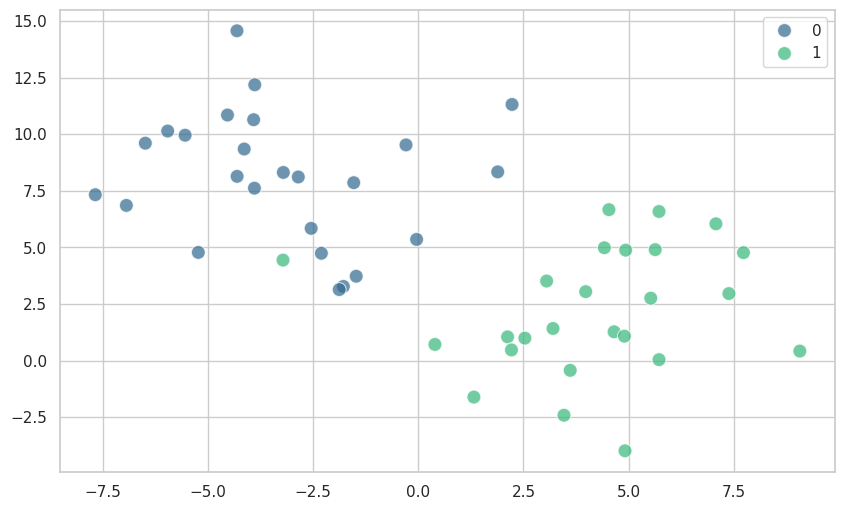

In [ ]:
from sklearn.datasets import make_blobs

# Generate a synthetic 2D dataset for the toy example
X_toy, y_toy = make_blobs(n_samples=50, centers=2, random_state=42, cluster_std=3.0)

#let's visualize the samples with the corresponding label as color
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_toy[:, 0], y=X_toy[:, 1], hue=y_toy, palette='viridis', s=100, alpha=0.7)

In [ ]:
y_toy

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0])

In [ ]:
# For simplicity in this visualization, we'll use a small k (e.g., k=5)
k_toy = 5
knn_toy = KNeighborsClassifier(n_neighbors=k_toy)
knn_toy.fit(X_toy, y_toy)


# Define a new point to classify
new_point = np.array([[-2.5, 3]])

# Find the k nearest neighbors to the new point
distances, indices = knn_toy.kneighbors(new_point)

# Predict the class of the new point
prediction = knn_toy.predict(new_point)

print(f"These are the labels of the {k_toy} newarest points on the training set: ", y_toy[indices])
print("This is the predicted label: ", prediction)

These are the labels of the 5 newarest points on the training set:  [[0 0 0 1 0]]
This is the predicted label:  [0]


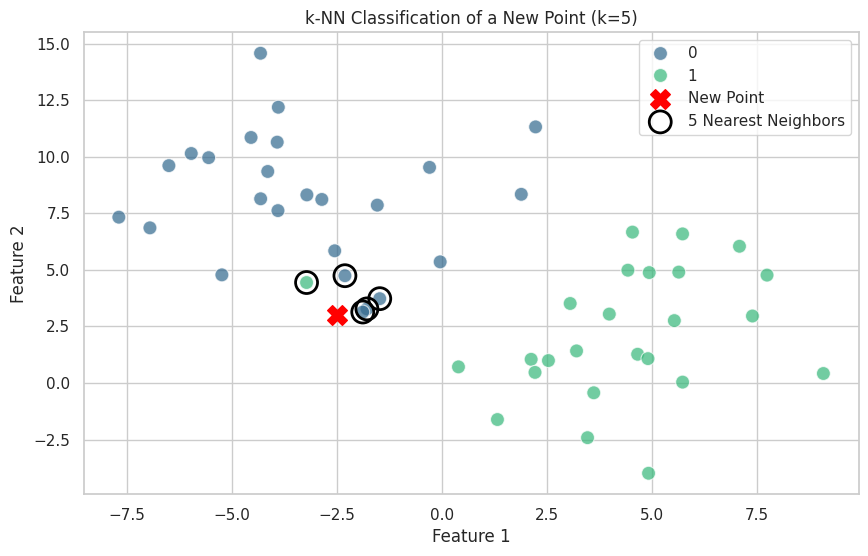

The new point at [-2.5  3. ] is predicted to belong to class: 0


In [ ]:
# Plot the dataset, the new point, and its neighbors
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_toy[:, 0], y=X_toy[:, 1], hue=y_toy, palette='viridis', s=100, alpha=0.7)
plt.scatter(new_point[:, 0], new_point[:, 1], color='red', marker='X', s=200, label='New Point')
plt.scatter(X_toy[indices, 0], X_toy[indices, 1], facecolors='none', edgecolors='black', s=250, linewidth=2, label=f'{k_toy} Nearest Neighbors')

plt.title(f'k-NN Classification of a New Point (k={k_toy})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"The new point at {new_point[0]} is predicted to belong to class: {prediction[0]}")

### 2. Adult Census Income Dataset

The **Adult Census Income dataset** is a widely used benchmark in machine learning for binary classification tasks. It originates from the 1994 Census database and contains information about individuals, with the primary goal being to predict whether an individual's income exceeds $50,000 per year or not (`>50K` vs. `<=50K`).

**Key Characteristics:**
*   **Target Variable:** Binary (income `>50K` or `<=50K`).
*   **Features:** A mix of numerical and categorical attributes, including:
    *   `age`: continuous.
    *   `workclass`: private, self-emp-not-inc, self-emp-inc, federal-gov, local-gov, state-gov, without-pay, never-worked.
    *   `fnlwgt`: continuous (final weight - the number of persons the census estimates that the row represents).
    *   `education`: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
    *   `education-num`: continuous (numerical representation of education level).
    *   `marital-status`: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
    *   `occupation`: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
    *   `relationship`: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
    *   `race`: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
    *   `sex`: Female, Male.
    *   `capital-gain`: continuous.
    *   `capital-loss`: continuous.
    *   `hours-per-week`: continuous.
    *   `native-country`: United-States, Cambodia, England, Puerto-Rico, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

This dataset is particularly useful for demonstrating preprocessing techniques such as one-hot encoding for categorical features and scaling for numerical features, as well as handling imbalanced classes (the `<=50K` class is significantly more prevalent than the `>50K` class).

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Load the Adult Census Income dataset
# This might take a moment to download if not already cached.
try:
    adult_data = fetch_openml(name='adult', version=2, as_frame=True)
except Exception as e:
    print(f"Could not load 'adult' version 2, trying 'adult' without version: {e}")
    adult_data = fetch_openml(name='adult', as_frame=True)

X_income = adult_data.data[::10] #let's sample rows to speed up the execution during the lecture
y_income = adult_data.target[::10]

print(f"Adult Census Income Dataset dimensions: {X_income.shape}")
print(f"Number of target classes: {len(y_income.unique())}")
print("Target classes:", y_income.unique())
print("First 5 rows of features (X_income):")
display(X_income.head())
print("First 5 target values (y_income):")
display(y_income.head())

Adult Census Income Dataset dimensions: (4885, 14)
Number of target classes: 2
Target classes: ['<=50K', '>50K']
Categories (2, object): ['<=50K', '>50K']
First 5 rows of features (X_income):


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
10,65,Private,184454,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States
20,34,Private,107914,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,47,United-States
30,46,State-gov,106444,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,7688,0,38,United-States
40,65,Private,136384,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States


First 5 target values (y_income):


,class
0,<=50K
10,>50K
20,>50K
30,>50K
40,>50K


In [ ]:
# Using the already loaded Adult Census Income dataset
# X_income and y_income are loaded from fetch_openml in cell 8095511c
df = pd.concat([X_income, y_income], axis=1) # Combine features and target into a single DataFrame for consistency with previous structure

print(f"Dataset dimensions: {df.shape}")
print(f"Target classes: {y_income.unique()}")

Dataset dimensions: (4885, 15)
Target classes: ['<=50K', '>50K']
Categories (2, object): ['<=50K', '>50K']


#### Class Distribution Analysis
It is crucial to check if the classes are balanced. Excessive imbalance can make accuracy a misleading metric (the Accuracy Trap).

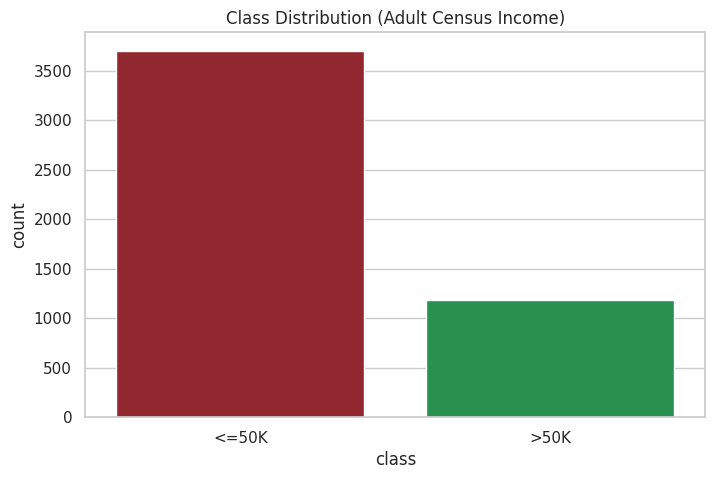

class
<=50K    0.75783
>50K     0.24217
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_income, palette=['#A31621', '#16A34A']) # Use y_income directly
plt.title('Class Distribution (Adult Census Income)') # Updated title
plt.xticks(ticks=range(len(y_income.unique())), labels=y_income.unique().categories.tolist()) # Update labels
plt.show()

print(y_income.value_counts(normalize=True)) # Use y_income directly

#### Preprocessing: Encoding, Scaling and Splitting

The Adult Census Income dataset contains both numerical and categorical features. Many algorithms (such as k-NN and Logistic Regression) require numerical input and are sensitive to feature scaling. Categorical features need to be converted into numerical representations (e.g., using **One-Hot Encoding**), and numerical features should be scaled.

We will use **One-Hot Encoding** for categorical features and **StandardScaler** to transform numerical features to have a mean of 0 and a variance of 1. This ensures that no single feature dominates the model's learning process due to its scale.

In [ ]:
X = X_income.copy() # Use X_income directly, make a copy to avoid modifying original
y = y_income.copy() # Use y_income directly, make a copy

# Convert target variable to numerical (0 or 1)
y = y.map({'<=50K': 0, '>50K': 1}).astype(int)

# Train-Test Split (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply one-hot encoding to handle categorical features.
# get_dummies will convert all categorical columns into numerical (binary) columns.
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns between training and test sets after one-hot encoding
# This ensures both sets have the same columns, adding missing ones as zeros.
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols] # Ensure column order is identical

# Feature Scaling: Apply StandardScaler to all features now that they are numerical
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Preprocessing completed.")

Preprocessing completed.


In [ ]:
# Creating and training the k-NN model (k=5)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_knn = knn.predict(X_test_scaled)

print(f"k-NN Accuracy (k=5): {accuracy_score(y_test, y_pred_knn):.4f}")

k-NN Accuracy (k=5): 0.8188


### The Impact of k
Let's see how accuracy varies with $k$. A $k$ that is too small can lead to **overfitting** (the model is too sensitive to noise), while a $k$ that is too large can lead to **underfitting** (the model is too simple).

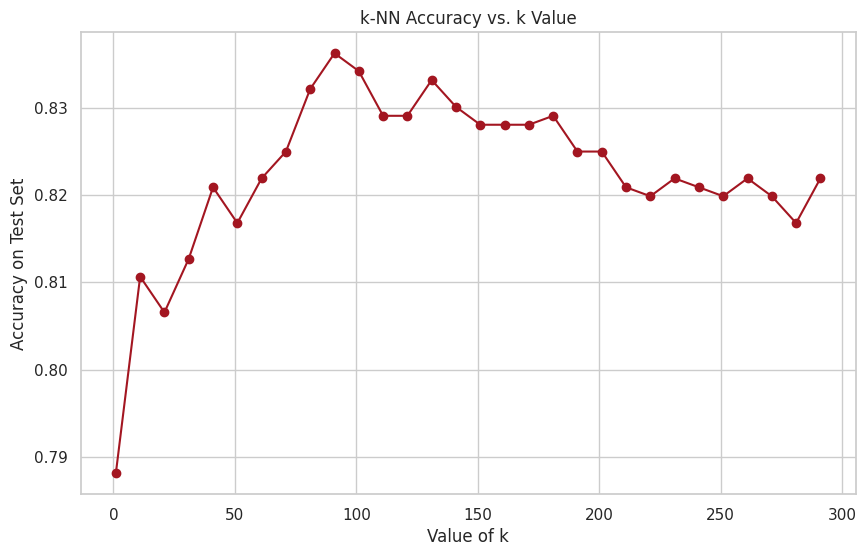

In [ ]:
k_values = range(1, 301, 10)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    accuracies.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', color='#A31621')
plt.title('k-NN Accuracy vs. k Value')
plt.xlabel('Value of k')
plt.ylabel('Accuracy on Test Set')
plt.show()

## 4. Logistic Regression

Unlike k-NN, Logistic Regression learns a **global rule**. It uses the **Sigmoid** function to map the linear output to a probability between 0 and 1.

### Logistic Regression Toy Example

Let's use a simple 2D toy dataset to visualize how Logistic Regression works by learning a linear decision boundary.

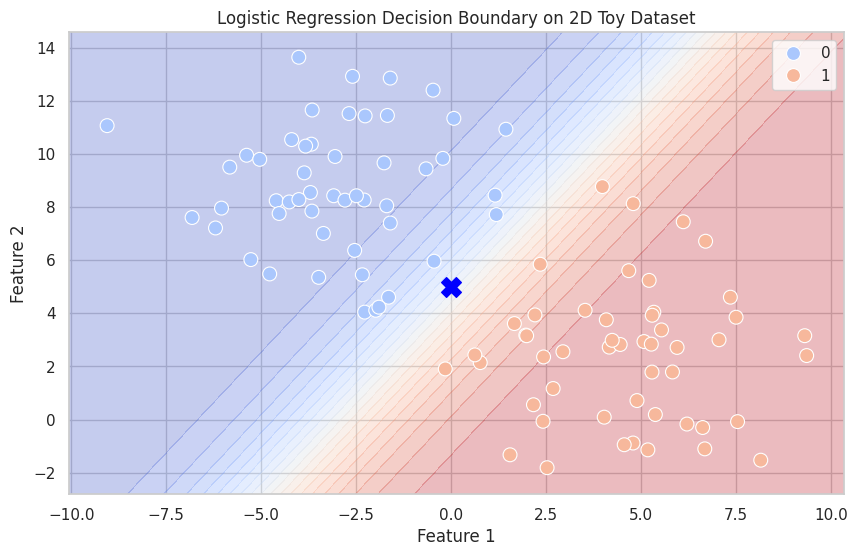

The new point at [0 5] is predicted to belong to class: 0


In [ ]:
from sklearn.datasets import make_blobs

# Generate a synthetic 2D dataset for the toy example
X_toy, y_toy = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.5)

# For simplicity in this visualization, we'll use the whole toy dataset for training
# In a real scenario, you would split it into train/test.

# Initialize and train a Logistic Regression model on the toy data
log_reg_toy = LogisticRegression(random_state=42, C=0.1)
log_reg_toy.fit(X_toy, y_toy)
pred = log_reg_toy.predict(X_toy)

# Create a new point to classify
new_point = np.array([[0, 5]])

# Predict the class of the new point
prediction_log_reg = log_reg_toy.predict(new_point)

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_toy[:, 0].min() - 1, X_toy[:, 0].max() + 1
y_min, y_max = X_toy[:, 1].min() - 1, X_toy[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = log_reg_toy.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=20) # Increased levels for smoother gradient
sns.scatterplot(x=X_toy[:, 0], y=X_toy[:, 1], hue=y_toy, palette='coolwarm', s=100, alpha=1)
plt.scatter(new_point[:, 0], new_point[:, 1], color='blue', marker='X', s=200)
plt.title('Logistic Regression Decision Boundary on 2D Toy Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"The new point at {new_point[0]} is predicted to belong to class: {prediction_log_reg[0]}")

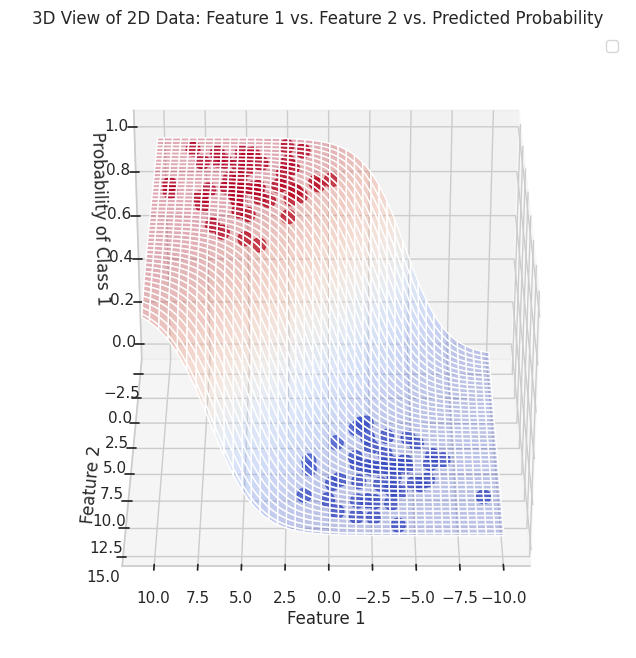

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# We will use the X_toy and y_toy from the previous 2D Logistic Regression example
# And the log_reg_toy model trained on this data

# Predict probabilities for each point in the X_toy dataset
probabilities = log_reg_toy.predict_proba(X_toy)[:, 1] # Probability of belonging to class 1

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of Feature 1, Feature 2, and Predicted Probability
scatter = ax.scatter(X_toy[:, 0], X_toy[:, 1], pred, c=y_toy, cmap='coolwarm', s=100, alpha=0.8)

# Plot the probability surface
ax.plot_surface(xx, yy, Z, cmap='coolwarm', alpha=0.3)

ax.set_title('3D View of 2D Data: Feature 1 vs. Feature 2 vs. Predicted Probability')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Probability of Class 1')

# Rotate 90 degrees along Z-axis (by setting azimuth to 90)
ax.view_init(elev=30, azim=90) # elev is elevation, azim is azimuth
ax.legend()
plt.show()

In [ ]:
# Creating and training the Logistic Regression model
log_reg = LogisticRegression(C=1.0, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Prediction on the test set
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

Logistic Regression Accuracy: 0.8465


### Impact of C on Decision Boundary
Let's visualize how different `C` values affect the decision boundary using our 2D toy dataset.

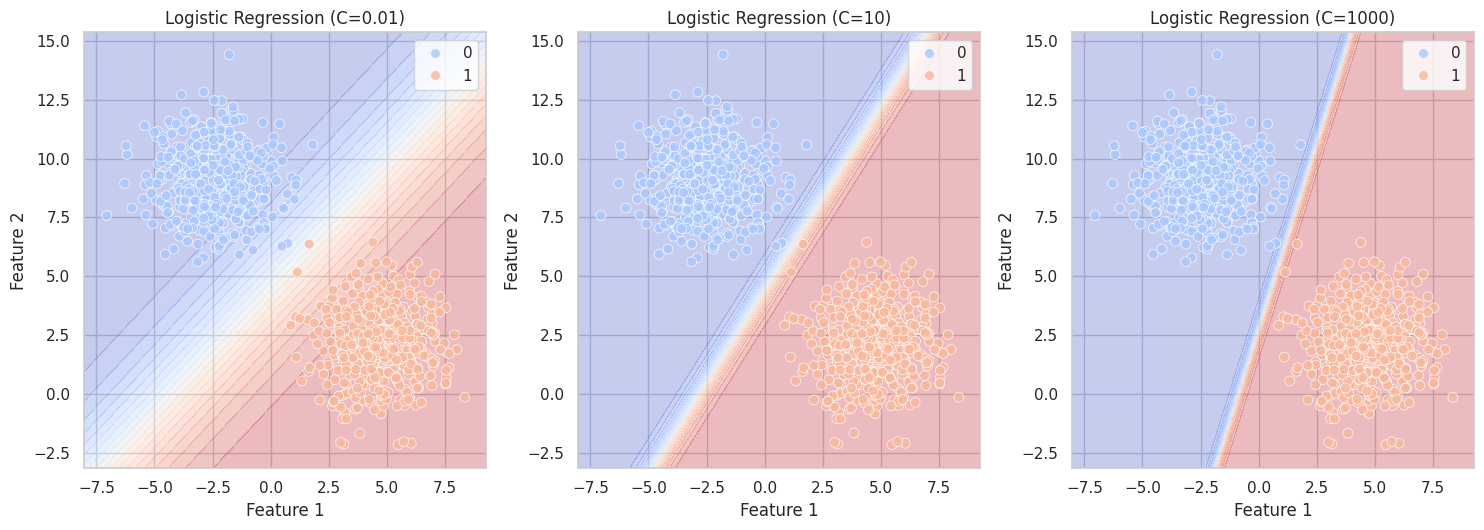

In [ ]:
from sklearn.datasets import make_blobs, make_moons, make_classification

# Generate a synthetic 2D dataset for the C effect visualization
X_toy_blobs, y_toy_blobs = make_blobs(centers=2, n_features=2, n_samples=1000, random_state=42, cluster_std=1.4)


# For simplicity, we won't scale this specific toy data here,
# as the focus is on the direct impact of C on the decision boundary
# of a linearly separable-ish dataset.

C_values = [0.01, 10, 1000]

plt.figure(figsize=(15, 10))

x_min, x_max = X_toy_blobs[:, 0].min() - 1, X_toy_blobs[:, 0].max() + 1
y_min, y_max = X_toy_blobs[:, 1].min() - 1, X_toy_blobs[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

for i, C_val in enumerate(C_values):
    log_reg_C = LogisticRegression(random_state=42, C=C_val)
    log_reg_C.fit(X_toy_blobs, y_toy_blobs)

    Z = log_reg_C.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=20)
    sns.scatterplot(x=X_toy_blobs[:, 0], y=X_toy_blobs[:, 1], hue=y_toy_blobs, palette='coolwarm', s=50, alpha=0.8)
    plt.title(f'Logistic Regression (C={C_val})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Optimization: Grid Search and Cross-Validation

Instead of trying parameters manually, we use **Grid Search** to systematically test different combinations, validating them with **Cross-Validation**.

### Grid Search with Pipelines

When performing Grid Search on a model that involves preprocessing steps (like scaling), it's crucial to incorporate these steps into a `Pipeline`. A `Pipeline` chains multiple processing steps together, ensuring that transformations are applied consistently and that hyperparameters are tuned correctly without **data leakage**.

Data leakage occurs when information from the test set 'leaks' into the training process, leading to overly optimistic performance estimates. By including the `StandardScaler` (or any other preprocessing step) within the `Pipeline` that is then passed to `GridSearchCV`, the scaling parameters (mean and standard deviation) are fitted *only* on the training folds of the cross-validation, and then applied to the validation folds. This is the correct procedure to avoid leakage and obtain reliable performance metrics.

**Note on Input to Pipeline**: In this setup, we will be providing the **unscaled (but one-hot encoded) features** (`X_train_encoded`) directly to the `GridSearchCV` that uses a pipeline. The `StandardScaler` step *within* the pipeline will then handle the scaling of these features before they are passed to the Logistic Regression model.

For Logistic Regression, the two main settings we adjust:
*   **`C` (Regularization Strength)**: Controls how simple or complex the model is.
    *   **Small `C`**: Strong regularization, simpler model, prevents overfitting.
    *   **Large `C`**: Weak regularization, more complex model, fits training data closely (risk of overfitting).
*   **`penalty` (Type of Regularization)**: Defines *how* the model is simplified.
    *   `'l1'` (Lasso): Makes some features irrelevant (coefficients become zero).
    *   `'l2'` (Ridge): Shrinks coefficients, preventing any single feature from becoming overly dominant.
    *   `'elasticnet'`: A mix of both 'l1' and 'l2'.

Best parameters: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}
Best Accuracy score (CV): 0.8534
Final Accuracy on Test Set: 0.8454


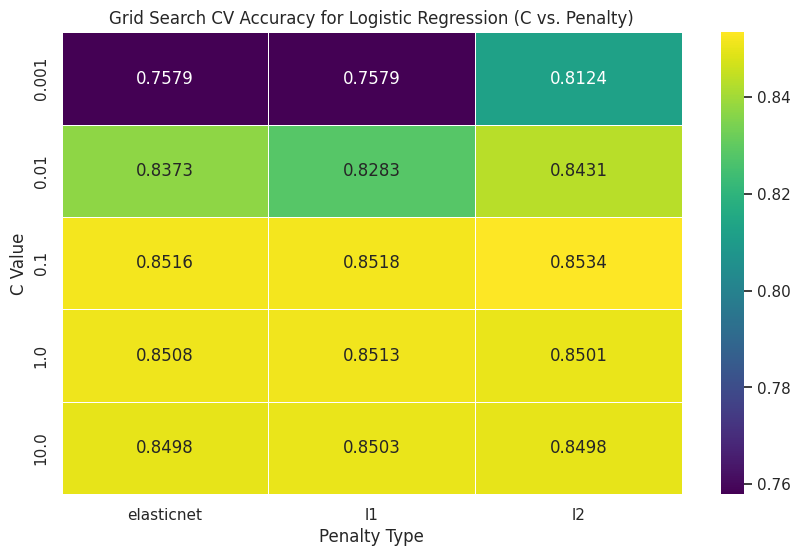

In [ ]:
# Define the pipeline with a scaler and Logistic Regression
pipeline_gridsearch = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(solver='saga', l1_ratio=0.5, max_iter=1000)) # Added max_iter for saga
])

# Define the parameter grid for GridSearchCV, now with pipeline step prefixes
# 'logisticregression__' refers to the 'logisticregression' step in the pipeline
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10],
    'logisticregression__penalty': ['l1','l2','elasticnet']
}

# Grid Search with 5-Fold Cross-Validation on the pipeline
# Fit the grid search on the unscaled, one-hot encoded training data
grid_search = GridSearchCV(pipeline_gridsearch, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_encoded, y_train) # Fit on X_train_encoded

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best Accuracy score (CV): {grid_search.best_score_:.4f}")

# Evaluating the best model (which is a pipeline) on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_encoded) # Predict on X_test_encoded
print(f"Final Accuracy on Test Set: {accuracy_score(y_test, y_pred_best):.4f}")

# Prepare data for visualization
results = pd.DataFrame(grid_search.cv_results_)

# Filter for relevant columns
# Note: parameter names in cv_results_ will include 'logisticregression__' prefix
results_filtered = results[['param_logisticregression__C', 'param_logisticregression__penalty', 'mean_test_score']]
results_filtered = results_filtered.rename(columns={
    'param_logisticregression__C': 'param_C',
    'param_logisticregression__penalty': 'param_penalty'
})

# Create a pivot table for heatmap
heatmap_data = results_filtered.pivot_table(index='param_C', columns='param_penalty', values='mean_test_score')

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title('Grid Search CV Accuracy for Logistic Regression (C vs. Penalty)')
plt.xlabel('Penalty Type')
plt.ylabel('C Value')
plt.show()

## 5. Model Evaluation

Accuracy is not everything. We need to understand **what errors** the model is making. We will use the **Confusion Matrix** and derived metrics.

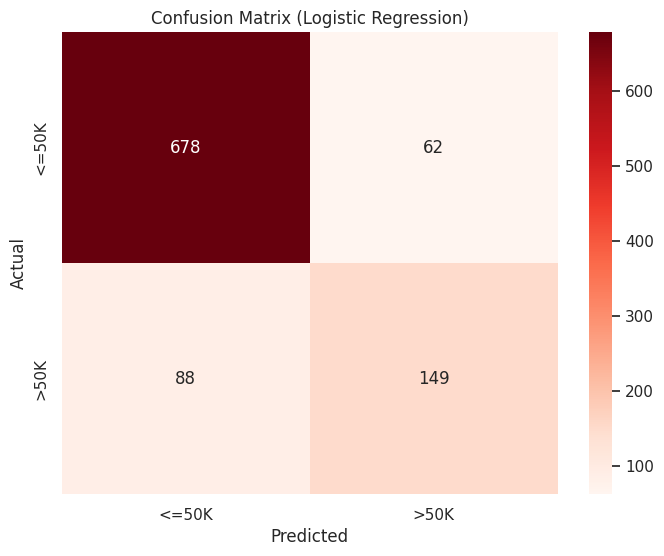

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90       740
        >50K       0.71      0.63      0.67       237

    accuracy                           0.85       977
   macro avg       0.80      0.77      0.78       977
weighted avg       0.84      0.85      0.84       977



In [ ]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)

# Get the unique classes from the original y_income to use as labels
original_target_names = y_income.unique().categories.tolist() # Convert categories to list of strings

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=original_target_names, yticklabels=original_target_names)
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=original_target_names))

### ROC Curve and AUC
The ROC curve shows the trade-off between True Positive Rate and False Positive Rate. The Area Under the Curve (AUC) measures the model's ability to distinguish between classes.

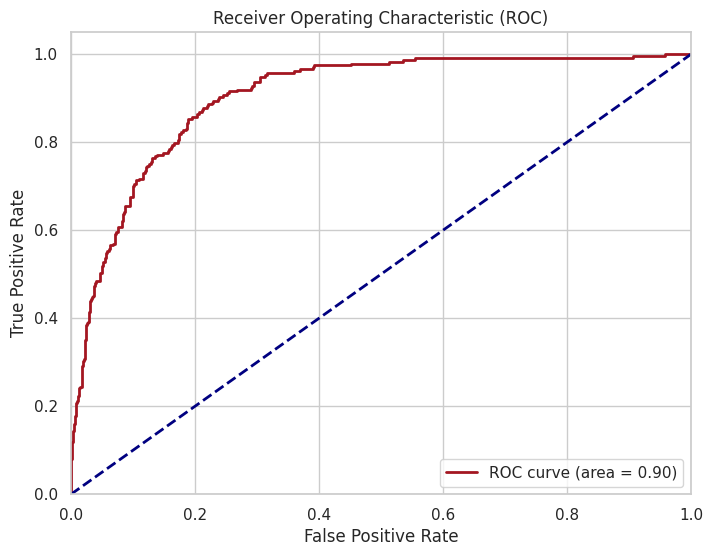

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#A31621', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## API References for ML Functions

For more detailed information on the machine learning functions used in this notebook, refer to the official scikit-learn documentation:

*   **`KNeighborsClassifier`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
*   **`LogisticRegression`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
*   **`StandardScaler`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
*   **`train_test_split`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
*   **`GridSearchCV`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
*   **`confusion_matrix`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
*   **`classification_report`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
*   **`roc_curve`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
*   **`auc`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html)
*   **`accuracy_score`**: [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)